In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Model From Scratch

In [118]:
class KNN:

    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        y_pred = []
        for i in X_test:
            distance = []

            for j in self.X_train:
                distance.append(self._calculate_distance(i ,j))
                
            neighbors = sorted(enumerate(distance), key=lambda x:x[1])[:self.n_neighbors]
            label = self._majority_count(neighbors)
            y_pred.append(label)

        return y_pred

    def _calculate_distance(self, a, b):
        return np.linalg.norm(a - b)

    def _majority_count(self, neighbors):
        votes = [self.y_train.iloc[i[0]] for i in neighbors]
        votes = Counter(votes)
        
        return votes.most_common()[0][0]

# Datasets

In [35]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [36]:
df.sample(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
48,12.05,14.63,78.04,449.3,0.10310,0.09092,0.06592,0.02749,0.1675,0.06043,...,20.70,89.88,582.6,0.1494,0.2156,0.30500,0.06548,0.2747,0.08301,1
219,19.53,32.47,128.00,1223.0,0.08420,0.11300,0.11450,0.06637,0.1428,0.05313,...,45.41,180.20,2477.0,0.1408,0.4097,0.39950,0.16250,0.2713,0.07568,0
286,11.94,20.76,77.87,441.0,0.08605,0.10110,0.06574,0.03791,0.1588,0.06766,...,27.29,92.20,546.1,0.1116,0.2813,0.23650,0.11550,0.2465,0.09981,1
146,11.80,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.07415,0.2678,0.07371,...,26.38,91.93,591.7,0.1385,0.4092,0.45040,0.18650,0.5774,0.10300,0
222,10.18,17.53,65.12,313.1,0.10610,0.08502,0.01768,0.01915,0.1910,0.06908,...,22.84,71.94,375.6,0.1406,0.1440,0.06572,0.05575,0.3055,0.08797,1


In [37]:
df.shape

(569, 31)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:-1], df.iloc[:,-1], test_size=0.2, random_state=32)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [40]:
X_test

array([[-0.62513452, -0.20477793, -0.59376348, ..., -0.00438418,
         0.76339276, -0.04526075],
       [-0.88738492, -0.46716908, -0.82469198, ...,  0.63994275,
        -0.58054838,  0.57961648],
       [ 0.05899694, -0.55387225, -0.05754668, ..., -1.2477652 ,
        -0.70914018, -1.24735961],
       ...,
       [-0.37998742, -0.58125219, -0.37935938, ..., -0.51969121,
         0.25216194,  0.05754682],
       [-0.85602889, -0.09525814, -0.75983371, ...,  2.13719168,
         1.95051463,  2.98809785],
       [ 0.03334201,  0.29262443,  0.02961953, ...,  0.30619067,
        -0.58995754, -0.31673697]])

# My model

In [122]:
myKnn = KNN()
myKnn.fit(X_train, y_train)

In [123]:
y_pred1 = myKnn.predict(X_test)
accuracy_score(y_test, y_pred1)

0.9824561403508771

# Using Sklearn

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [42]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)

0.9824561403508771

In [50]:
# Experimental Approach

score = []

for i in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    score.append(accuracy_score(y_test, y_pred))

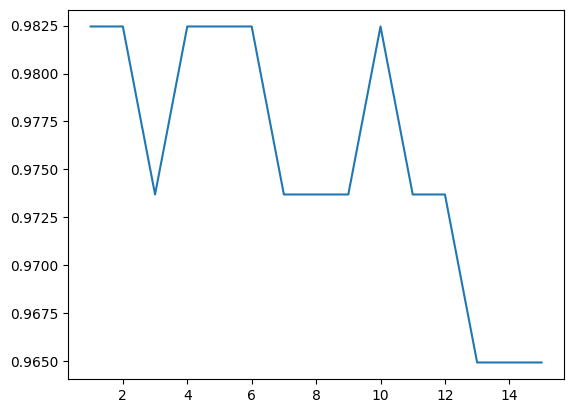

In [51]:
plt.plot(range(1,16), score)